In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
import pandas as pd

plt.rcParams['text.usetex'] = True

from utils import *

from tqdm.notebook import tqdm

In [2]:
N1 = 80
N2 = 20

N = N1 +  N2

Delta = 25
delta = 0.5
lam = 0.001

Nt = 500
dt = 0.1

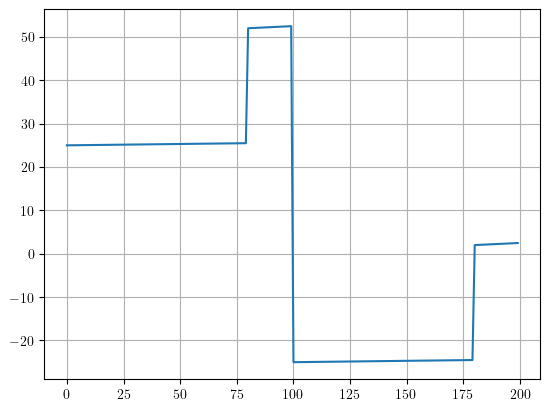

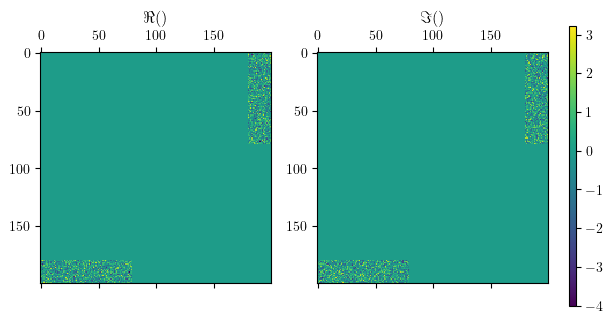

In [3]:
H_B = np.zeros([N,N])
H_B[:N1,:N1] += np.diag(np.arange(N1)*delta/N1)
H_B[N1:,N1:] += np.diag(np.arange(N1,N)*delta/N2+Delta)

H_0 = Delta*np.kron(Z(),np.eye(N)) + np.kron(np.eye(2),H_B)

plt.figure()
plt.plot(np.diag(H_0))
plt.grid()
plt.show()


B = np.zeros([N,N], dtype=np.complex128)
B[:N1,N1:] = (np.random.randn(N1*N2) + 1j*np.random.randn(N1*N2)).reshape([N1,N2])

V = np.kron(P(),B) + np.kron(M(),B.H)

plot_matrix(V)

H = H_0 + lam*V

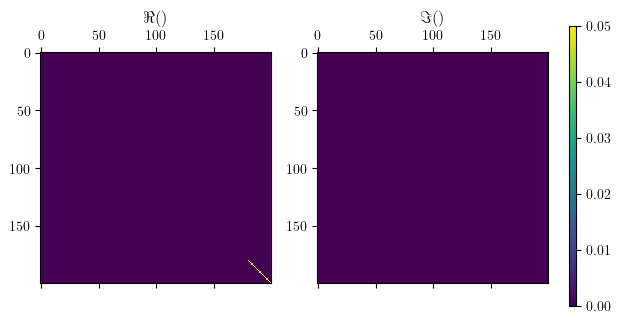

1.0


In [4]:
rho_E_0 = np.zeros([N,N])
# for n1 in range(N1):
#     rho_E_0 += ketbra(n1,n1,N)/N1
for n2 in range(N1,N):
    rho_E_0 += ketbra(n2,n2,N)/N2
rho_0 = np.kron(ketbra(1,1,2), rho_E_0)

plot_matrix(rho_0)
print(np.trace(rho_0))

In [5]:
U = sp.linalg.expm(-1j*H*dt)

X = np.kron(ketbra(1,1,2),np.eye(N))

def out(rho):
    return np.real(np.trace(X@rho))

rho_t = rho_0

ys = [out(rho_t)]

for j in range(Nt):
    rho_t = U @ rho_t @ U.H
    ys.append(out(rho_t))

ys = np.array(ys)

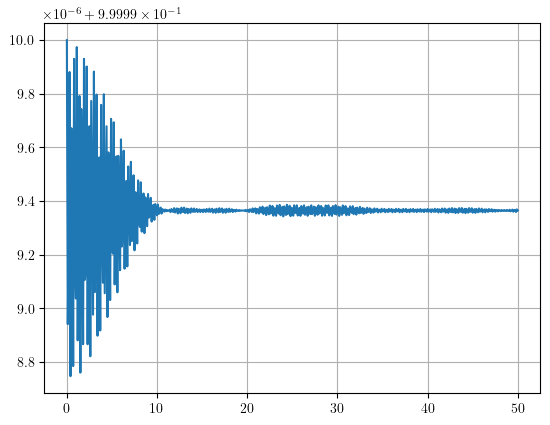

In [6]:
ts = np.arange(Nt+1)*dt

plt.figure()
plt.plot(ts,ys)
plt.grid()
plt.show()
